In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:

df = pd.read_csv('C:/Users/DELL/AIT 506/student_por.csv')

print(df.head(10))
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4   at_home   teacher   
1     GP   F   17       U     GT3       T     1     1   at_home     other   
2     GP   F   15       U     LE3       T     1     1   at_home     other   
3     GP   F   15       U     GT3       T     4     2    health  services   
4     GP   F   16       U     GT3       T     3     3     other     other   
5     GP   M   16       U     LE3       T     4     3  services     other   
6     GP   M   16       U     LE3       T     2     2     other     other   
7     GP   F   17       U     GT3       A     4     4     other   teacher   
8     GP   M   15       U     LE3       A     3     2  services     other   
9     GP   M   15       U     GT3       T     3     4     other     other   

   ... famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0  ...      4        3      4     1     1      3        4   0  11  11  
1  ...  

In [3]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(len(categorical_columns))

print("\nNumerical columns:")
print(len(numerical_columns))

Categorical columns:
17

Numerical columns:
16


C:\Users\DELL\AppData\Local\Temp\ipykernel_12060\93766995.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [4]:
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

print(df.head())

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         4   0  11  11  
1       5         3      3     1     1       3         2   9  11  11  
2       4         3      2     2     3       3         6  12  13  12  
3       3         2      2     1     1       5         0  14  14  14  
4       4         3      2     1     2       5         0  11  13  13  

[5 rows x 33 columns]


In [5]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13
5,0,1,16,1,1,1,4,3,3,2,...,5,4,2,1,2,5,6,12,12,13
6,0,1,16,1,1,1,2,2,2,2,...,4,4,4,1,1,3,0,13,12,13
7,0,0,17,1,0,0,4,4,2,4,...,4,1,4,1,1,1,2,10,13,13
8,0,1,15,1,1,0,3,2,3,2,...,4,2,2,1,1,1,0,15,16,17
9,0,1,15,1,0,1,3,4,2,2,...,5,5,1,1,1,5,0,12,12,13


In [6]:
print(df.dtypes)

school        int64
sex           int64
age           int64
address       int64
famsize       int64
Pstatus       int64
Medu          int64
Fedu          int64
Mjob          int64
Fjob          int64
reason        int64
guardian      int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
activities    int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [7]:
correlation_with_G3 = df.corr(numeric_only=True)["G3"].sort_values(ascending=False)

print(correlation_with_G3)


G3            1.000000
G2            0.918548
G1            0.826387
higher        0.332172
studytime     0.249789
Medu          0.240151
Fedu          0.211800
address       0.167637
internet      0.150025
Mjob          0.148252
reason        0.124969
famrel        0.063361
activities    0.059791
famsup        0.059206
Fjob          0.052953
famsize       0.045016
nursery       0.028752
Pstatus      -0.000754
paid         -0.054898
schoolsup    -0.066405
guardian     -0.079609
goout        -0.087641
romantic     -0.090583
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
sex          -0.129077
Walc         -0.176619
Dalc         -0.204719
school       -0.284294
failures     -0.393316
Name: G3, dtype: float64


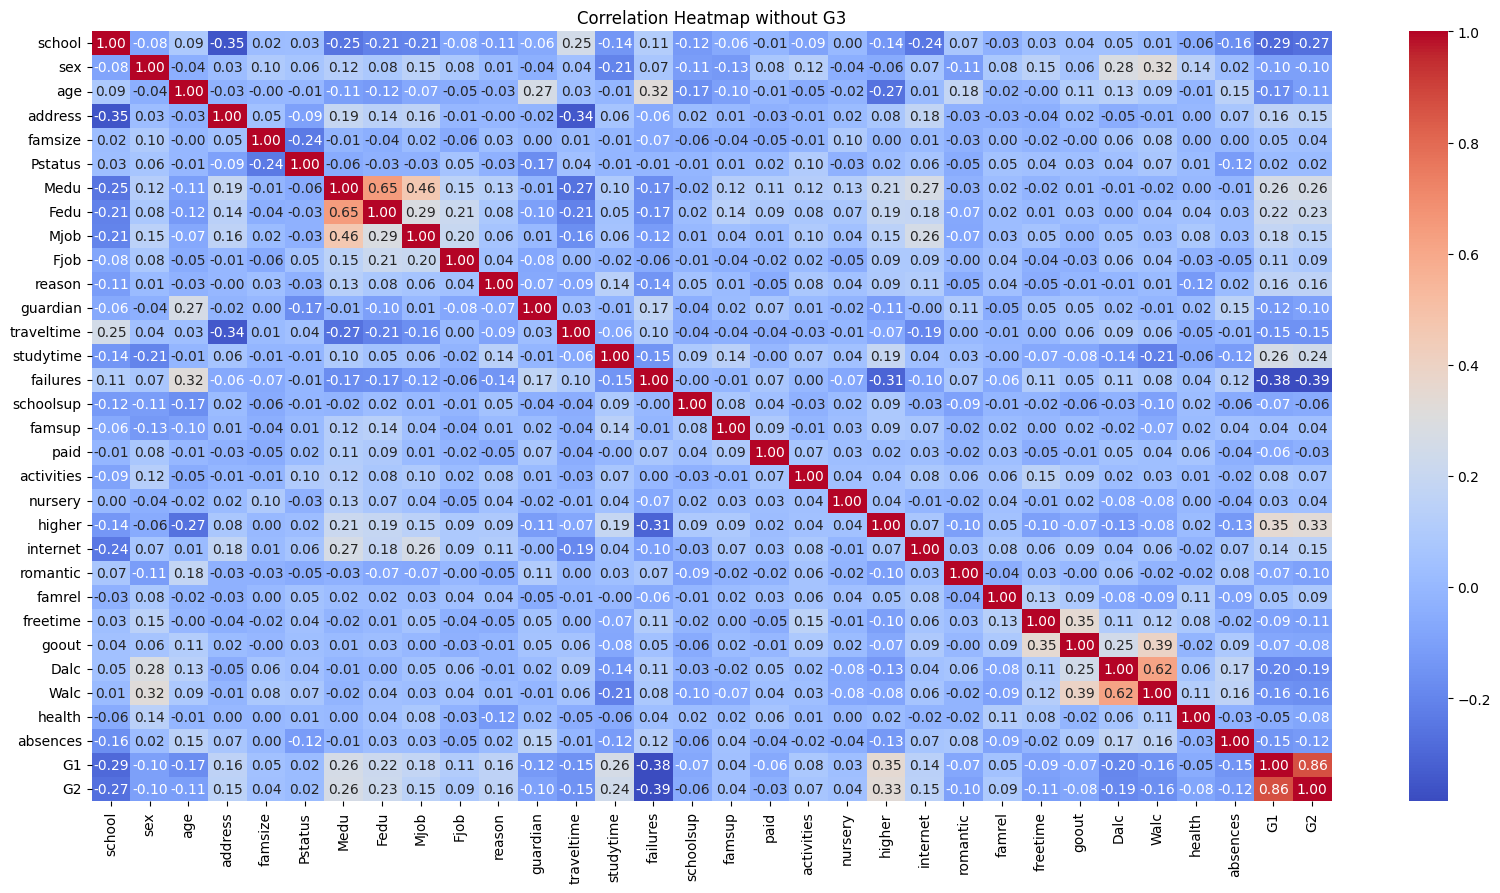

In [8]:
corr = df.corr(numeric_only=True)
corr = corr.drop(index="G3", columns="G3")

plt.figure(figsize=(20, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap without G3")
plt.show()

In [9]:
corr_with_G3 = df.corr(numeric_only=True)["G3"].drop("G3")

selected_features = corr_with_G3[abs(corr_with_G3) >= 0.21].index.tolist()

df_selected = df[selected_features + ["G3"]]

print(df_selected.head())
print(df_selected.columns)


   school  Medu  Fedu  studytime  failures  higher  G1  G2  G3
0       0     4     4          2         0       1   0  11  11
1       0     1     1          2         0       1   9  11  11
2       0     1     1          2         0       1  12  13  12
3       0     4     2          3         0       1  14  14  14
4       0     3     3          2         0       1  11  13  13
Index(['school', 'Medu', 'Fedu', 'studytime', 'failures', 'higher', 'G1', 'G2',
       'G3'],
      dtype='str')


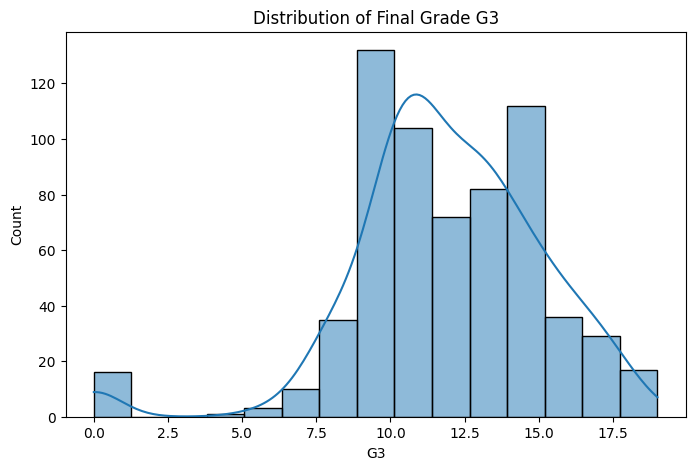

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_selected["G3"], bins=15, kde=True)
plt.title("Distribution of Final Grade G3")
plt.xlabel("G3")
plt.ylabel("Count")
plt.show()


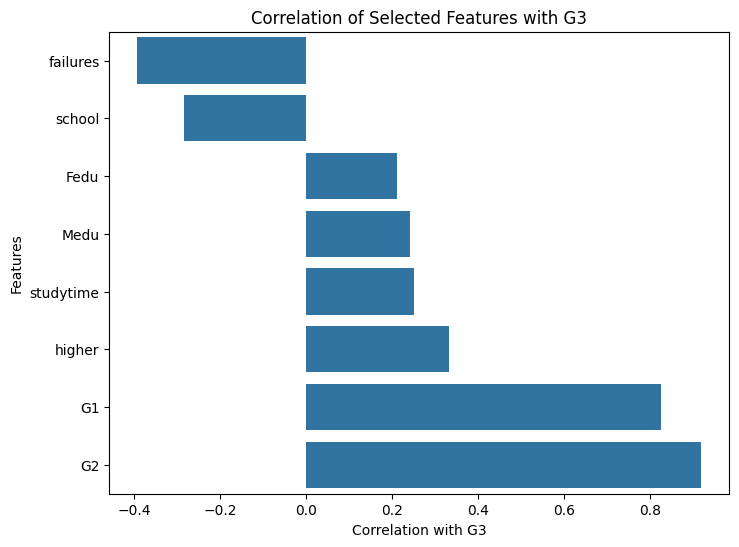

In [11]:
corr_with_G3 = df_selected.corr(numeric_only=True)["G3"].drop("G3").sort_values()

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_G3.values, y=corr_with_G3.index)
plt.title("Correlation of Selected Features with G3")
plt.xlabel("Correlation with G3")
plt.ylabel("Features")
plt.show()


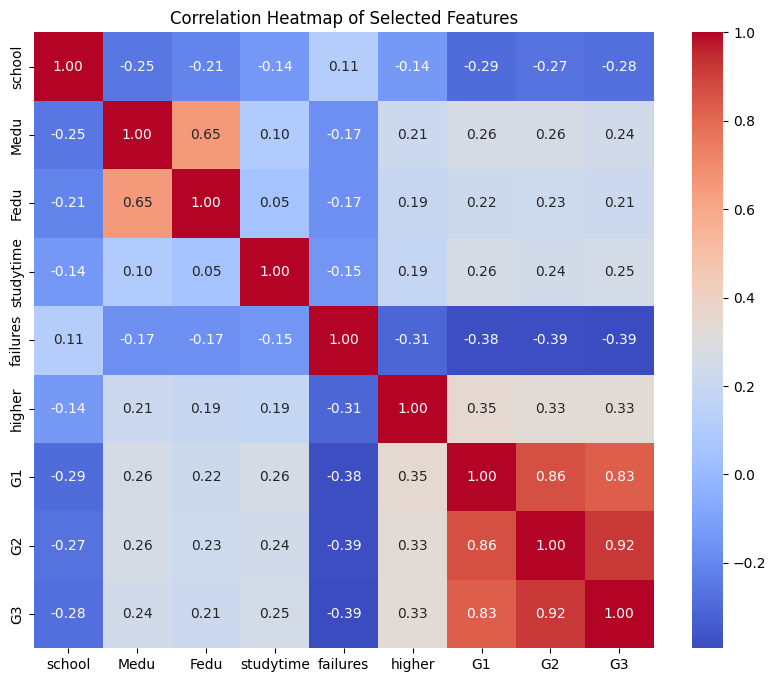

In [12]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_selected.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Selected Features")
plt.show()


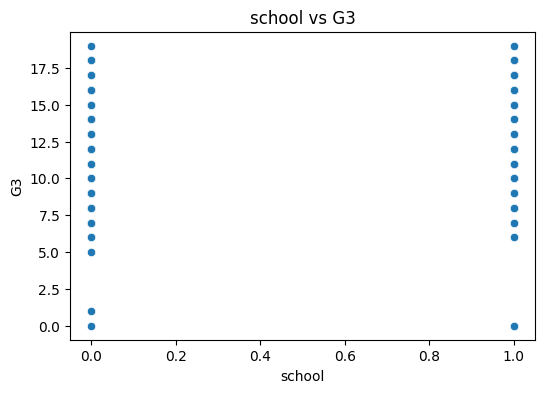

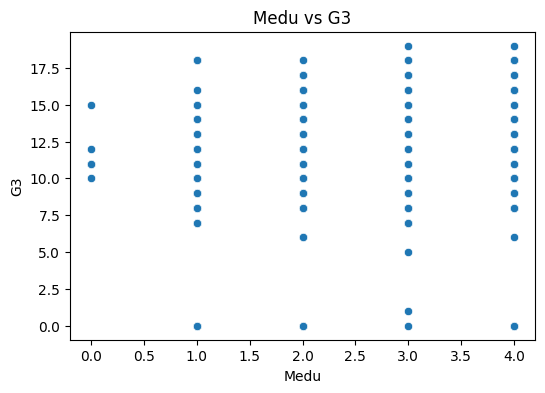

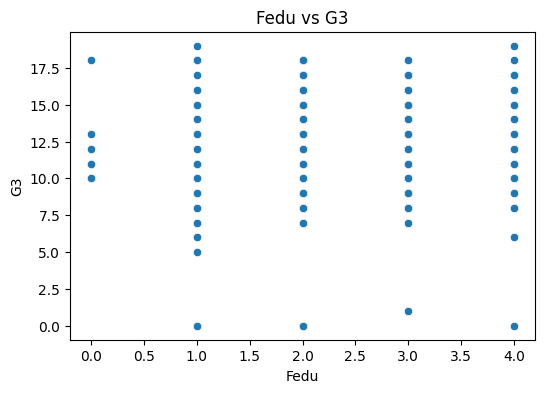

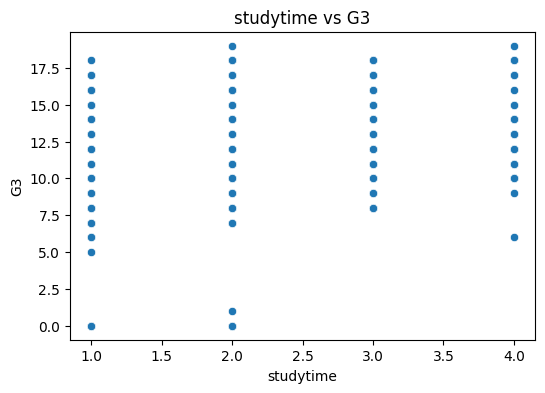

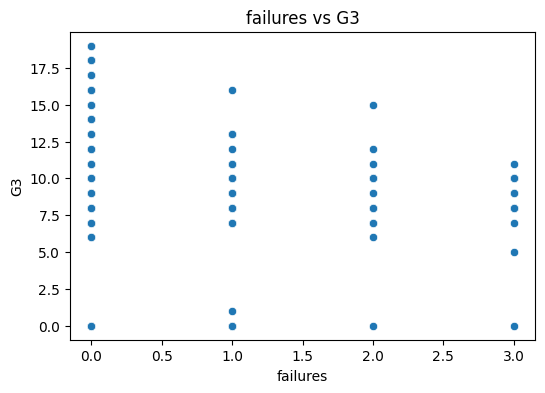

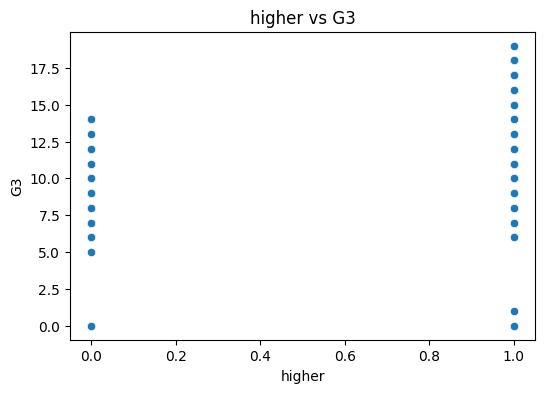

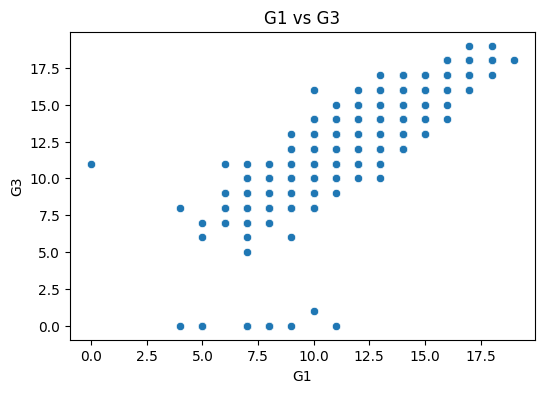

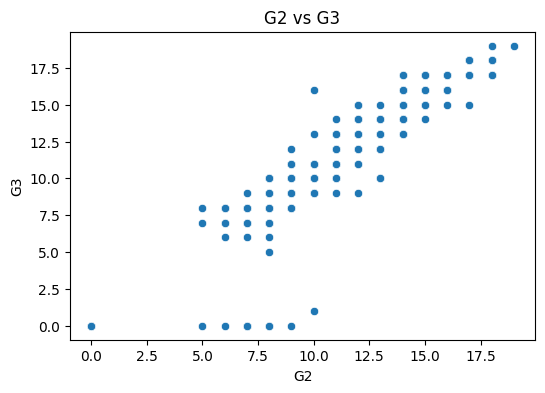

In [13]:
for column in selected_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df_selected, x=column, y="G3")
    plt.title(f"{column} vs G3")
    plt.xlabel(column)
    plt.ylabel("G3")
    plt.show()


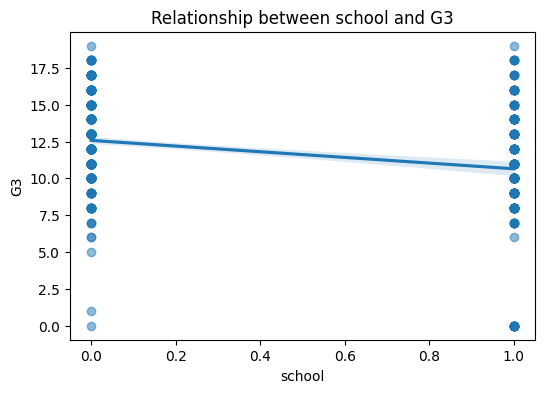

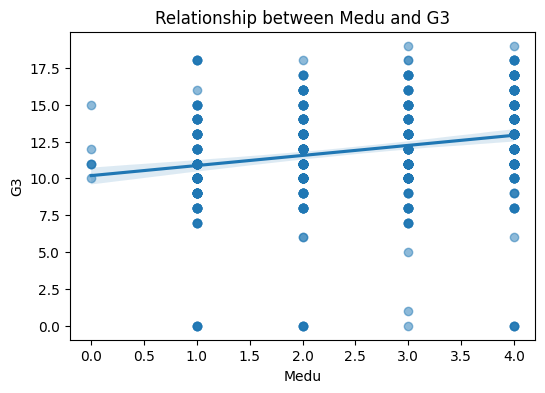

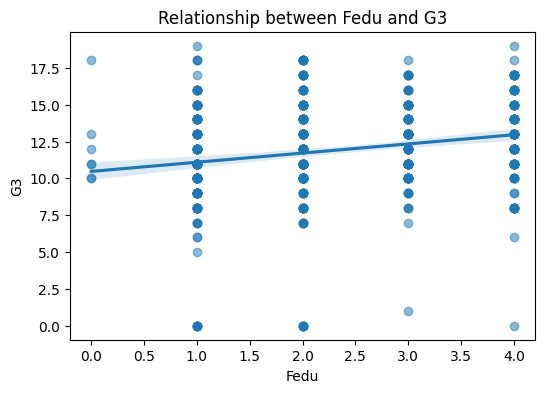

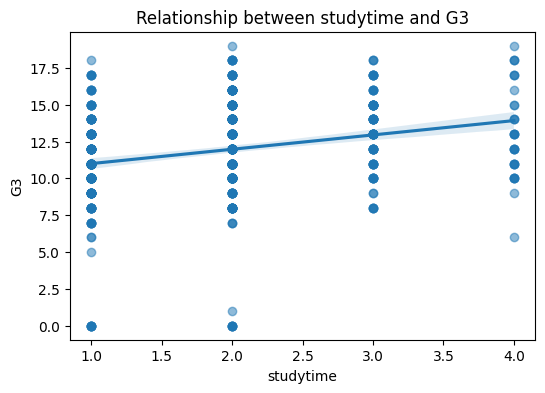

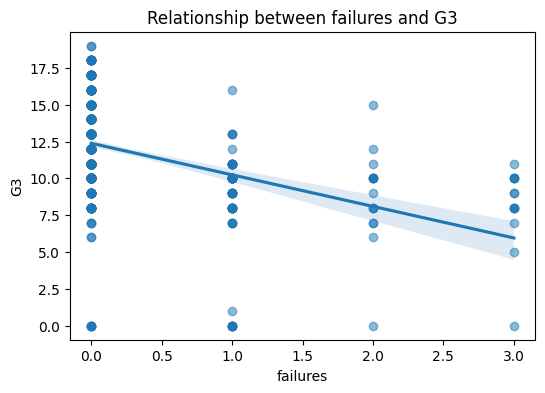

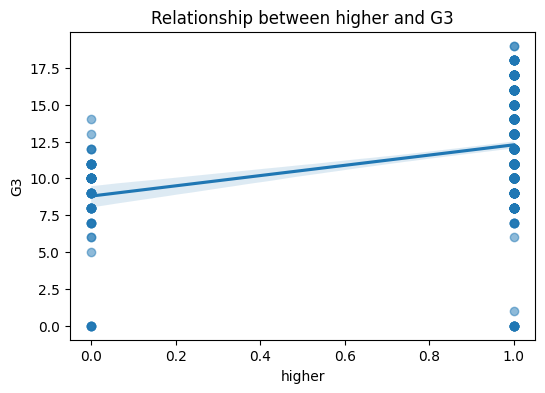

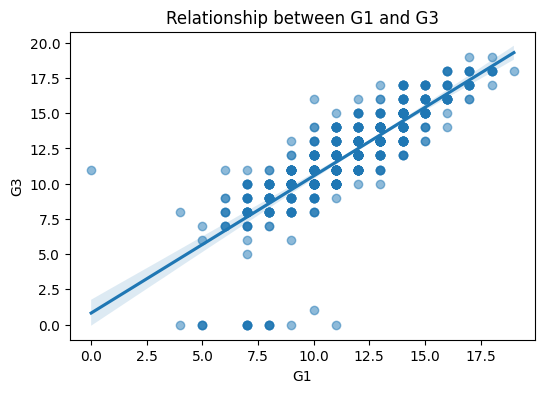

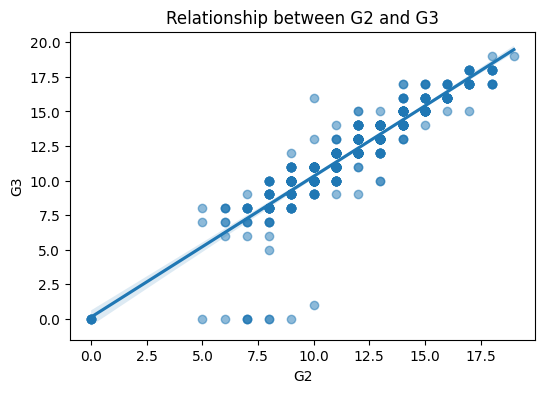

In [14]:
for column in selected_features:
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df_selected, x=column, y="G3", scatter_kws={"alpha": 0.5})
    plt.title(f"Relationship between {column} and G3")
    plt.xlabel(column)
    plt.ylabel("G3")
    plt.show()


In [15]:
#Scaling
from sklearn.preprocessing import StandardScaler
df_processed = df_selected.copy()

#Missing values
print(df_processed.isnull().sum())



school       0
Medu         0
Fedu         0
studytime    0
failures     0
higher       0
G1           0
G2           0
G3           0
dtype: int64


In [16]:
feature_columns = df_processed.drop(columns=["G3"]).columns

for column in feature_columns:
    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_processed[
        (df_processed[column] < lower_bound) |
        (df_processed[column] > upper_bound)
    ]

    print(column, ":", outliers.shape[0], "outliers")


school : 0 outliers
Medu : 0 outliers
Fedu : 0 outliers
studytime : 35 outliers
failures : 100 outliers
higher : 69 outliers
G1 : 16 outliers
G2 : 25 outliers


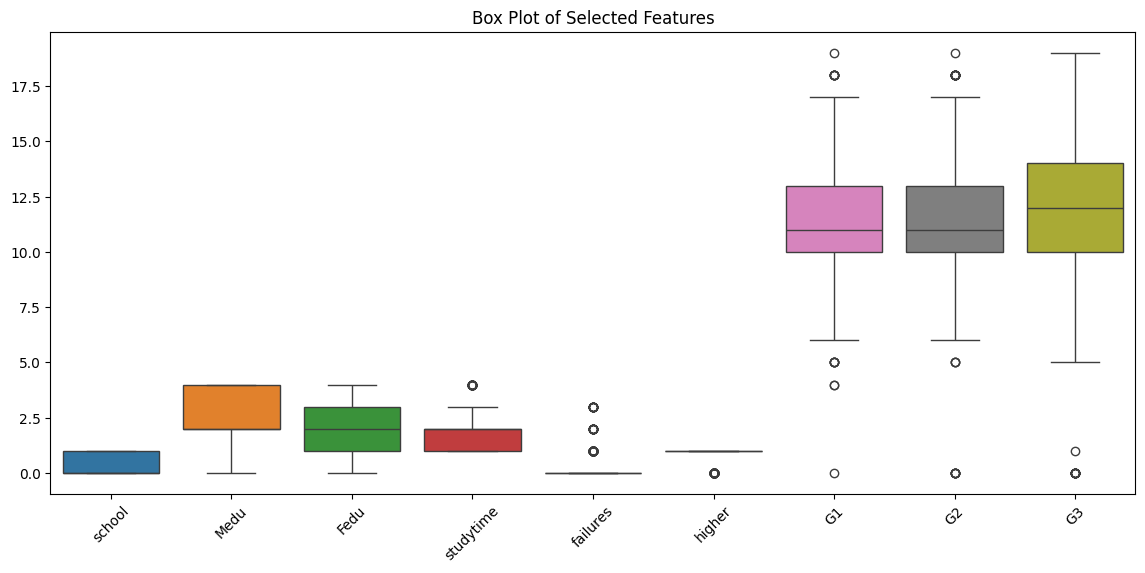

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.boxplot(data=df_selected)

plt.title("Box Plot of Selected Features")
plt.xticks(rotation=45)
plt.show()


In [18]:
#Handle outlier
for column in feature_columns:
    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_processed[column] = df_processed[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )


In [19]:
for column in feature_columns:
    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_processed[
        (df_processed[column] < lower_bound) |
        (df_processed[column] > upper_bound)
    ]

    print(column, ":", outliers.shape[0], "outliers")


school : 0 outliers
Medu : 0 outliers
Fedu : 0 outliers
studytime : 0 outliers
failures : 0 outliers
higher : 0 outliers
G1 : 0 outliers
G2 : 0 outliers


In [20]:
#Scaline 0 to 1 to minimize loss function
scaler = StandardScaler()

df_processed[feature_columns] = scaler.fit_transform(df_processed[feature_columns])


In [21]:
print(df_processed.head(10))


     school      Medu      Fedu  studytime  failures  higher        G1  \
0 -0.730944  1.310216  1.540715   0.125568       0.0     0.0 -2.206630   
1 -0.730944 -1.336039 -1.188832   0.125568       0.0     0.0 -0.899455   
2 -0.730944 -1.336039 -1.188832   0.125568       0.0     0.0  0.220979   
3 -0.730944  1.310216 -0.278983   1.429466       0.0     0.0  0.967936   
4 -0.730944  0.428131  0.630866   0.125568       0.0     0.0 -0.152499   
5 -0.730944  1.310216  0.630866   0.125568       0.0     0.0  0.220979   
6 -0.730944 -0.453954 -0.278983   0.125568       0.0     0.0  0.594458   
7 -0.730944  1.310216  1.540715   0.125568       0.0     0.0 -0.525977   
8 -0.730944  0.428131 -0.278983   0.125568       0.0     0.0  1.341414   
9 -0.730944  0.428131  1.540715   0.125568       0.0     0.0  0.220979   

         G2  G3  
0 -0.230013  11  
1 -0.230013  11  
2  0.513590  12  
3  0.885391  14  
4  0.513590  13  
5  0.141789  13  
6  0.141789  13  
7  0.513590  13  
8  1.628994  17  
9  0.

In [22]:
print(df_processed["G3"].describe())
print(df_processed["G3"].value_counts().sort_index())

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Creating classification target
df_model = df_processed.copy()
df_model["performance"] = df_selected["G3"].apply(lambda x: 1 if x >= 10 else 0)

#Spliting features and target
X = df_model.drop(columns=["G3", "performance"])
y = df_model["performance"]
print(y.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)



performance
1    549
0    100
Name: count, dtype: int64


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predictions on training data
y_train_pred = model.predict(X_train)

# Predictions on test data
y_test_pred = model.predict(X_test)

# Training performance


print("Training Performance")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))

print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))


# Test performance

print("\nTest Performance")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Training Performance
Accuracy: 0.9441233140655106
Precision: 0.9591836734693877
Recall: 0.9746543778801844
F1 Score: 0.9668571428571429

Training Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        85
           1       0.96      0.97      0.97       434

    accuracy                           0.94       519
   macro avg       0.91      0.88      0.89       519
weighted avg       0.94      0.94      0.94       519


Test Performance
Accuracy: 0.9076923076923077
Precision: 0.9478260869565217
Recall: 0.9478260869565217
F1 Score: 0.9478260869565217

Test Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        15
           1       0.95      0.95      0.95       115

    accuracy                           0.91       130
   macro avg       0.77      0.77      0.77       130
weighted avg       0.91      0.91      0.91       130



In [25]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

if train_accuracy - test_accuracy > 0.10:
    print("The model may be overfitting because training accuracy is much higher than testing accuracy.")
else:
    print("There is no strong sign of overfitting because the training and testing performance are close.")


Training Accuracy: 0.9441233140655106
Testing Accuracy: 0.9076923076923077
Difference: 0.03643100637320296
There is no strong sign of overfitting because the training and testing performance are close.


Training Confusion Matrix:
[[ 67  18]
 [ 11 423]]

Testing Confusion Matrix:
[[  9   6]
 [  6 109]]


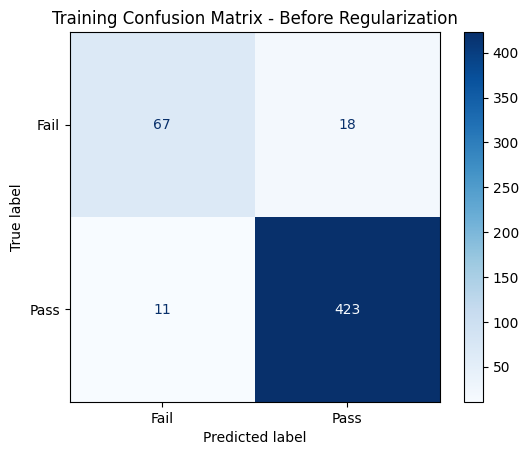

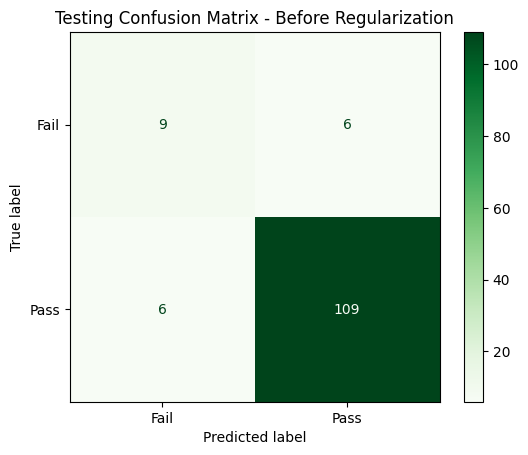

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions using original model
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Confusion matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

print("Training Confusion Matrix:")
print(train_cm)

print("\nTesting Confusion Matrix:")
print(test_cm)

# Plot training confusion matrix
train_display = ConfusionMatrixDisplay(
    confusion_matrix=train_cm,
    display_labels=["Fail", "Pass"]
)

train_display.plot(cmap="Blues")
plt.title("Training Confusion Matrix - Before Regularization")
plt.show()

# Plot testing confusion matrix
test_display = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["Fail", "Pass"]
)

test_display.plot(cmap="Greens")
plt.title("Testing Confusion Matrix - Before Regularization")
plt.show()


Confusion Matrix:
[[  9   6]
 [  6 109]]


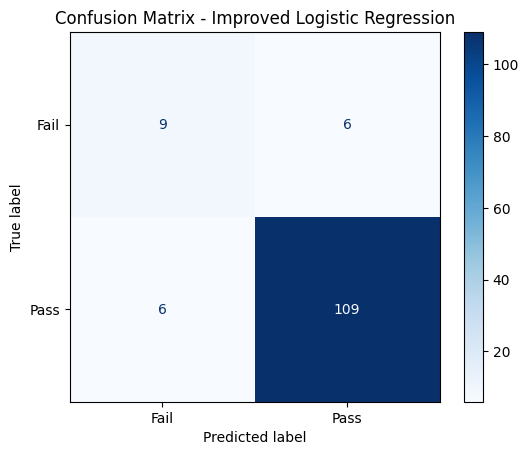

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Improved Logistic Regression")
plt.show()


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Creating Logistic Regression model with regularization


regularized_model = LogisticRegression(
    penalty="l2",
    C=0.1,
    max_iter=1000,
    random_state=42
)

# Applying cross-validation


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    regularized_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


# Training improved model

regularized_model.fit(X_train, y_train)


# Evaluating improved model

y_train_pred = regularized_model.predict(X_train)
y_test_pred = regularized_model.predict(X_test)

print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTraining F1 Score:", f1_score(y_train, y_train_pred))
print("Testing F1 Score:", f1_score(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Cross-validation scores: [0.91538462 0.92307692 0.95384615 0.93076923 0.89922481]
Mean CV Accuracy: 0.9244603458556947
Standard Deviation: 0.018024666121228262

Training Accuracy: 0.9402697495183044
Testing Accuracy: 0.9076923076923077

Training F1 Score: 0.9650507328072153
Testing F1 Score: 0.9482758620689655

Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57        15
           1       0.94      0.96      0.95       115

    accuracy                           0.91       130
   macro avg       0.78      0.74      0.76       130
weighted avg       0.90      0.91      0.90       130



C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

Wrong target distribution:
performance
1    549
0    100
Name: count, dtype: int64


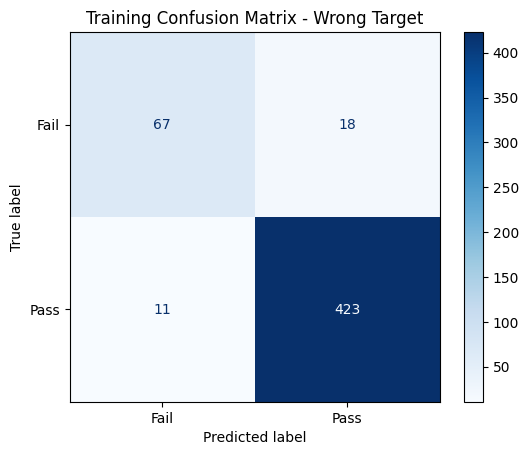

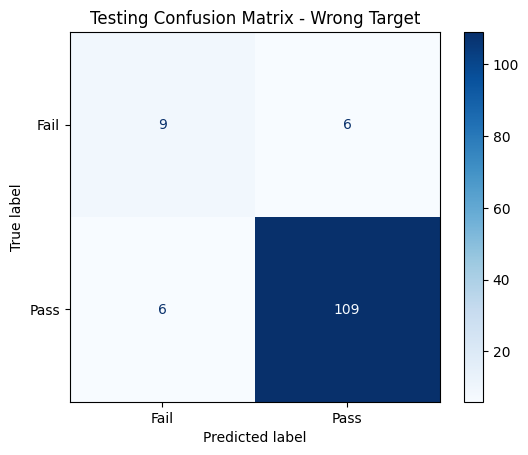

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Wrong target created from processed/scaled G3
df_wrong = df_processed.copy()
df_wrong["performance"] = df_wrong["G3"].apply(lambda x: 1 if x >= 10 else 0)

X_wrong = df_wrong.drop(columns=["G3", "performance"])
y_wrong = df_wrong["performance"]

print("Wrong target distribution:")
print(y_wrong.value_counts())

X_train_wrong, X_test_wrong, y_train_wrong, y_test_wrong = train_test_split(
    X_wrong,
    y_wrong,
    test_size=0.2,
    random_state=42
)

wrong_model = LogisticRegression(max_iter=1000)
wrong_model.fit(X_train_wrong, y_train_wrong)

y_train_wrong_pred = wrong_model.predict(X_train_wrong)
y_test_wrong_pred = wrong_model.predict(X_test_wrong)

# Training confusion matrix
train_wrong_cm = confusion_matrix(y_train_wrong, y_train_wrong_pred)

ConfusionMatrixDisplay(
    confusion_matrix=train_wrong_cm,
    display_labels=["Fail", "Pass"]
).plot(cmap="Blues")

plt.title("Training Confusion Matrix - Wrong Target")
plt.show()

# Testing confusion matrix
test_wrong_cm = confusion_matrix(y_test_wrong, y_test_wrong_pred)

ConfusionMatrixDisplay(
    confusion_matrix=test_wrong_cm,
    display_labels=["Fail", "Pass"]
).plot(cmap="Blues")

plt.title("Testing Confusion Matrix - Wrong Target")
plt.show()


In [30]:
for c_value in [0.001, 0.01, 0.1, 1, 10]:
    model = LogisticRegression(
        penalty="l2",
        C=c_value,
        max_iter=1000,
        random_state=42
    )

    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    print("C =", c_value)
    print("Mean CV Accuracy:", scores.mean())
    print()


C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

C = 0.001
Mean CV Accuracy: 0.8459153249850925

C = 0.01
Mean CV Accuracy: 0.8736672629695885

C = 0.1
Mean CV Accuracy: 0.9244603458556947

C = 1
Mean CV Accuracy: 0.9275491949910555

C = 10
Mean CV Accuracy: 0.9306261180679785



C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

In [31]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score

model = LogisticRegression(
    penalty="l2", 
    C=10,  
    max_iter=1000,
    random_state=42
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


recall_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
print(f"Recall for Fail class across folds: {recall_scores}")
print(f"Mean Recall (Fail): {recall_scores.mean():.4f}")

f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
print(f"Mean F1 Score: {f1_scores.mean():.4f}")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n" + "="*50)
print("CONFUSION MATRIX ON TEST SET")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,cm.sum())
print(f"\nTrue Negatives (Fail correct): {tn}")
print(f"False Negatives (Fail→Pass): {fn}")
print(f"Recall for Fail class: {tn/(tn+fp) if (tn+fp)>0 else 0:.4f}")

Recall for Fail class across folds: [0.96363636 0.97272727 0.95454545 0.99090909 0.96330275]
Mean Recall (Fail): 0.9690
Mean F1 Score: 0.9594

CONFUSION MATRIX ON TEST SET
[[ 10   5]
 [  6 109]]

True Negatives (Fail correct): 10
False Negatives (Fail→Pass): 6
Recall for Fail class: 0.6667


C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

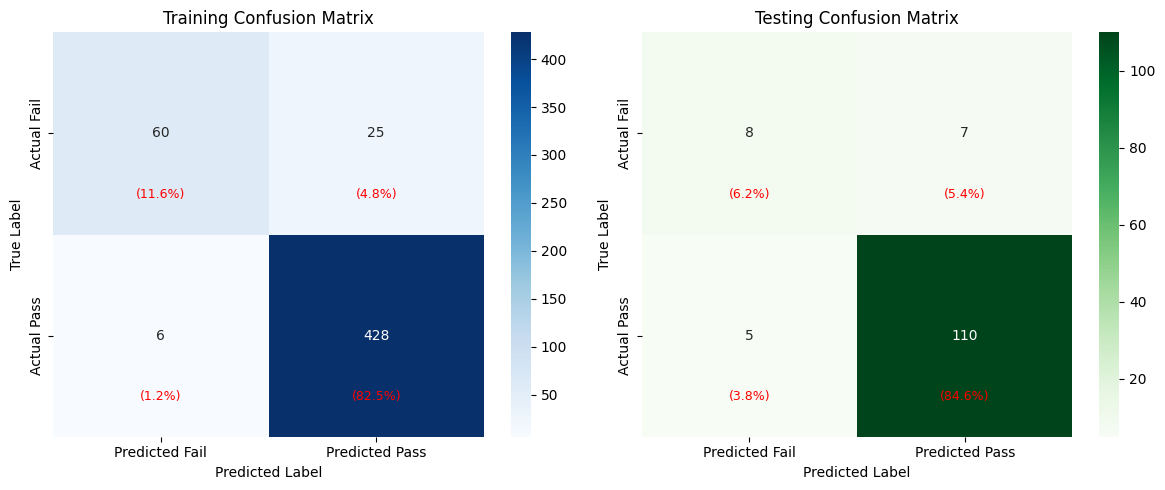

TRAINING SET METRICS
Confusion Matrix:
[[ 60  25]
 [  6 428]]

True Negatives (Fail correctly predicted): 60
False Positives (Pass predicted as Fail): 25
False Negatives (Fail predicted as Pass): 6
True Positives (Pass correctly predicted): 428

TESTING SET METRICS
Confusion Matrix:
[[  8   7]
 [  5 110]]

True Negatives (Fail correctly predicted): 8
False Positives (Pass predicted as Fail): 7
False Negatives (Fail predicted as Pass): 5
True Positives (Pass correctly predicted): 110


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_train_pred = regularized_model.predict(X_train)
y_test_pred = regularized_model.predict(X_test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

total_train = len(y_train)
for i in range(2):
    for j in range(2):
        percent = cm_train[i, j] / total_train * 100
        ax1.text(j+0.5, i+0.8, f'({percent:.1f}%)', 
                ha='center', va='center', color='red', fontsize=9)

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
ax2.set_title('Testing Confusion Matrix')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

total_test = len(y_test)
for i in range(2):
    for j in range(2):
        percent = cm_test[i, j] / total_test * 100
        ax2.text(j+0.5, i+0.8, f'({percent:.1f}%)', 
                ha='center', va='center', color='red', fontsize=9)

plt.tight_layout()
plt.show()


print("TRAINING SET METRICS")
print(f"Confusion Matrix:\n{cm_train}")
print(f"\nTrue Negatives (Fail correctly predicted): {cm_train[0,0]}")
print(f"False Positives (Pass predicted as Fail): {cm_train[0,1]}")
print(f"False Negatives (Fail predicted as Pass): {cm_train[1,0]}")
print(f"True Positives (Pass correctly predicted): {cm_train[1,1]}")


print("\nTESTING SET METRICS")
print(f"Confusion Matrix:\n{cm_test}")
print(f"\nTrue Negatives (Fail correctly predicted): {cm_test[0,0]}")
print(f"False Positives (Pass predicted as Fail): {cm_test[0,1]}")
print(f"False Negatives (Fail predicted as Pass): {cm_test[1,0]}")
print(f"True Positives (Pass correctly predicted): {cm_test[1,1]}")